In [1]:
#required packages. Make sure all these are installed in your prefered working environment. I can show you how to do this 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import scipy.stats
import seaborn as sns
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import math
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
proteins=pd.read_excel("format for Jupyter analysis.xlsx")
proteins

,Gene,Genotype,Replicate,Abundance
0,Fabp10a,Control,1,1.6
1,Fabp10a,Control,2,1.4
2,Fabp10a,Control,3,1.6
3,Fabp10a,c865,1,199.3
4,Fabp10a,c865,2,204.7
...,...,...,...,...
181,Ela3l,Control,2,198.1
182,Ela3l,Control,3,184.5
183,Ela3l,c865,1,7.5
184,Ela3l,c865,2,9.2


In [3]:
state=["Control","c865"]
genes={}
i=0
ratio_dict=[]
for gene in proteins["Gene"]:
    if gene in genes: 
        i+=1
        genes.update({gene:i})
    else:
        i=1
        genes[gene]=i
for gene in genes: 
    if genes[gene]==6:
        controls=list(proteins[(proteins.Genotype=="Control")&(proteins.Gene==gene)]["Abundance"].sample(n=3,replace=False))
        mutants=list(proteins[(proteins.Genotype=="c865")&(proteins.Gene==gene)]["Abundance"].sample(n=3,replace=False))
    else: 
        controls=list(proteins[(proteins.Genotype=="Control")&(proteins.Gene==gene)]["Abundance"].sample(n=3,replace=True))
        mutants=list(proteins[(proteins.Genotype=="c865")&(proteins.Gene==gene)]["Abundance"].sample(n=3,replace=True))
    for j in range(0,3):
        ratio_dict.append({"Gene":gene,"Replicate":j+1,"log2fold Change":math.log(mutants[j]/controls[j])}) 
ratios=pd.DataFrame(ratio_dict)

<Figure size 640x480 with 0 Axes>

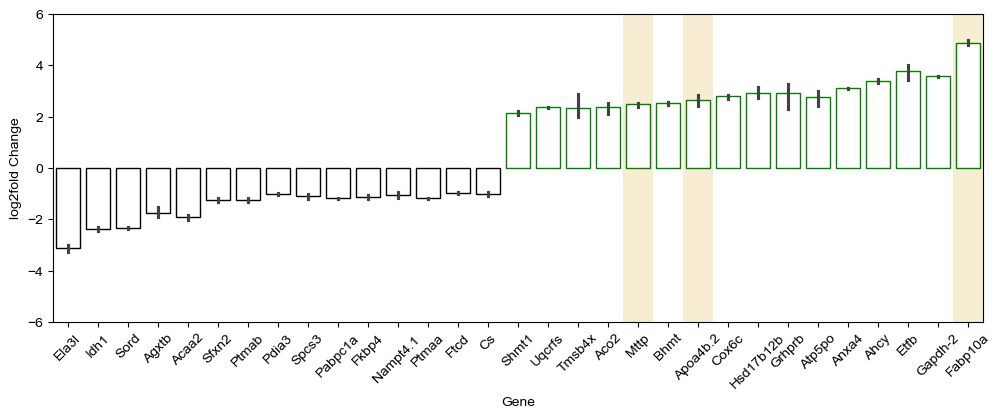

In [24]:
fig,ax=plt.subplots(1,1,figsize=(12,4))

sns.barplot(data=ratios.iloc[::-1],x="Gene",y="log2fold Change",ax=ax,edgecolor='green', color='white')
i=0
for bar in ax.patches:
    if i<15:
        bar.set_edgecolor('black')
        i+=1
ax.axvspan(29.5, 30.5, facecolor='goldenrod', alpha=0.2,zorder=-100)
ax.axvspan(20.5, 21.5, facecolor='goldenrod', alpha=0.2,zorder=-100)
ax.axvspan(18.5, 19.5, facecolor='goldenrod', alpha=0.2,zorder=-100)
ax.set(ylim=[-6,6])
ax.set(xlim=[-0.5,30.5])
plt.xticks(rotation=45)
plt.show()
plt.savefig("AsgrFigure5D.svg")

In [4]:
ratios

,Gene,Replicate,log2fold Change
0,Fabp10a,1,4.784884
1,Fabp10a,2,4.958339
2,Fabp10a,3,4.851542
3,Gapdh-2,1,3.451309
4,Gapdh-2,2,3.566005
...,...,...,...
88,Idh1,2,-2.305841
89,Idh1,3,-2.388223
90,Ela3l,1,-3.137010
91,Ela3l,2,-2.998446


In [6]:
pd.set_option('display.max_rows', 500)
signif=pd.read_excel("STATS_KEGG_Zebrafish_ASGR1.xlsx")
signif[(signif["P-value"]<0.05)].to_csv("sig.csv")